### Statement ###

Solving the problem

$$\begin{align*}
    -k \nabla u &= v\\
    \nabla \cdot v &= 0 \\
    u &= g_D \qquad             &\text{on } \Gamma_D \\
    v &= h = (h_1,\,h_2) \qquad &\text{on } \Gamma_N,
\end{align*}
$$

where $k$ is assumed piecewise smooth.
The boundary conditions of $v = (v_1,\,v_2)$ on $\Gamma_N$ translate to

$$ \begin{align*}
    \partial_x u &= h_1 \\
    \partial_y u &= h_2
\end{align*} $$

In [177]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [178]:
import copy
import h5py
import matplotlib.pyplot as plt
import numpy as np
import sys
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau

sys.path.append('../..')

from src import train, utils
from src.calculus import L2_norm
import src.data.cube_domain as cb
import src.models.expert_chars as ec
import src.models.mlp_model as mm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]


In [179]:
def k(x: torch.Tensor) -> torch.Tensor:
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 2).unsqueeze(1)


def g_D(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * (x[:, 0:1] + 1)


def u_0(x: torch.Tensor) -> torch.Tensor:
    return 1 - x[:, 0:1]**2


def v_0(x: torch.Tensor) -> torch.Tensor:
    shape = 1 - x[:, 1:2]**2                   # (N,1), zero when y=+-1
    ones  = torch.ones(x.shape[0], 1, device=x.device)
    return torch.cat([ones, shape], dim=1)       # (N,2)


def h(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([torch.zeros_like(x[:, 0:1]), x[:, 1:2]], dim=1)


def chi(x):
    return torch.where(torch.norm(x, p=2, dim=1) < 0.5, 1, 0).float().unsqueeze(1)


In [180]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=30_000,
    N_sides=[(0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)
print(f'Interior points: {domain.interior.shape}')


Interior points: torch.Size([30000, 2])


## Training characteristics ##

In [181]:
def loss_char_for_val(k_value):
    def loss_char(model, domain): 
        x = domain.interior.requires_grad_(True)
        k_vals = k(x)
        u = model(x)
        err_sq = torch.where(k_vals - k_value == 0, (u - 1)**2, u**2)
        return [torch.mean(err_sq)]
    return loss_char

In [182]:
model_char_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    layer=[64, 64, 64, 64, 64],
    last_layer_activation='relu',
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
)

model_char = mm.MLPModel(model_char_ctx).to(device=device)
char_optim = torch.optim.Adam(model_char.parameters(), lr=1e-4)

In [183]:
train_ctx = train.TrainingContext(
    model=model_char,
    domain=domain,
    optimizer=char_optim,
    loss_fn=loss_char_for_val(k_value=1.0),
    epochs=60_000,
    monitor_gradient=True,
    monitor_lr=True,
)

loss_exp, loss_comps_exp = train.train_switch_to_lbfgs(train_ctx, lbfgs_lr=0.1, epochs_with_lbfgs=1_000)

Loss at epoch 1 is: 0.1674889773130417. Total gradient norm: 0.2503139865782528 Current learing rate: 0.0001 
Loss at epoch 100 is: 0.13638520240783691. Total gradient norm: 0.06597209676522173 Current learing rate: 0.0001 
Loss at epoch 200 is: 0.05478869751095772. Total gradient norm: 0.07553486519101794 Current learing rate: 0.0001 
Loss at epoch 300 is: 0.03939139097929001. Total gradient norm: 0.014355086118154732 Current learing rate: 0.0001 
Loss at epoch 400 is: 0.033632513135671616. Total gradient norm: 0.020469857022574995 Current learing rate: 0.0001 
Loss at epoch 500 is: 0.027104582637548447. Total gradient norm: 0.0196727701831228 Current learing rate: 0.0001 
Loss at epoch 600 is: 0.019383996725082397. Total gradient norm: 0.01737640059290806 Current learing rate: 0.0001 
Loss at epoch 700 is: 0.014798719435930252. Total gradient norm: 0.012302876192825 Current learing rate: 0.0001 
Loss at epoch 800 is: 0.011683667078614235. Total gradient norm: 0.010157080679172611 Cur

In [184]:
model_char.requires_grad_(False)
cutoff = 0.5

def chi_learned(x):
    u = model_char(x)
    return (u >= cutoff).float()

In [1]:
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=['Environment permeability'],
    function_names=['k'],
    colour_map='jet',
    vmin=0,
    vmax=2,
    device=device,
    N=1500,
    save_img=True,
)

plot_ctx.save_path = './darcy_learned_pou/environment_permeability.png'
utils.plot_function_on_2d_cube([k], plot_ctx)

plot_ctx.save_path = './darcy_learned_pou/learned_pou.png'
plot_ctx.titles = ["Learned pou"]
utils.plot_function_on_2d_cube([chi_learned], plot_ctx)

NameError: name 'utils' is not defined

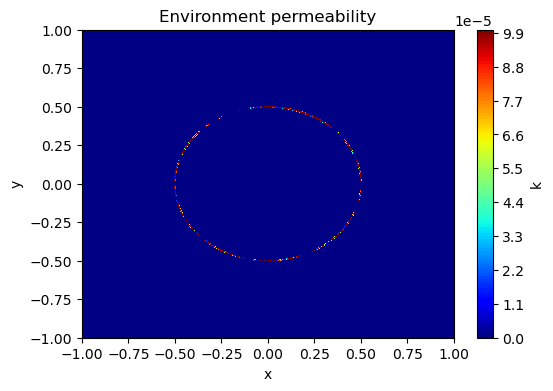

In [ ]:
plot_ctx.vmin = 0.0
plot_ctx.vmax = 0.0001

plot_ctx.save_path = './darcy_learned_pou/pou_error.png'
plot_ctx.titles = ['Pou error']
utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(chi_learned(x) - chi(x)), 0.0, 0.0001)], plot_ctx)

## Boundary of the region model ##

The point of this model is to learn the curve which separates the region of different k values, i. e. learn a certain level set of model_char. We will then sample gradiets of model_char on this model, to abtain normal vectors to constant k_value regions.

In [187]:
from matplotlib import contour
from skimage import measure

N = 1300

x = torch.linspace(-1, 1, N)
y = torch.linspace(-1, 1, N)
X, Y = torch.meshgrid(x, y)

inp = torch.column_stack((X.reshape(-1),Y.reshape(-1))).to(device)
outp = model_char(inp).detach().cpu().numpy().reshape(N, N)

contour = measure.find_contours(outp, cutoff)[0]

# find_contours returns (row, col) as floats – interpolate properly
row_f, col_f = contour[:, 0], contour[:, 1]  # sub-pixel float indices

x_np = torch.linspace(-1, 1, N).numpy()
y_np = torch.linspace(-1, 1, N).numpy()

# Linear interpolation instead of truncation
cx = np.interp(row_f, np.arange(N), x_np)
cy = np.interp(col_f, np.arange(N), y_np)
contour_tensor = torch.tensor(np.column_stack([cx, cy]), dtype=torch.float32, device=device)


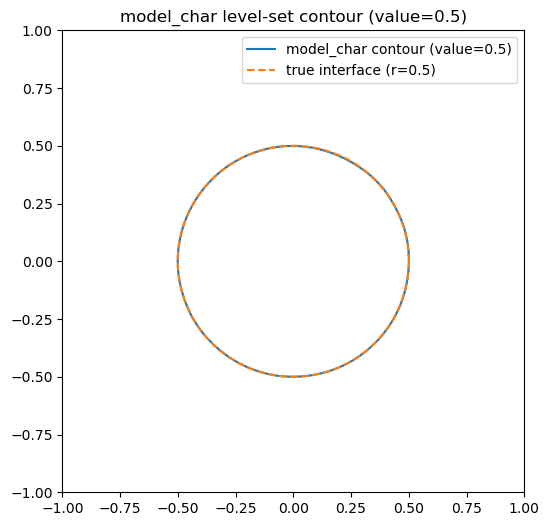

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

pts = contour_tensor.cpu().numpy()
ax.plot(pts[:, 0], pts[:, 1], color='tab:blue', linewidth=1.5, label=f'model_char contour (value={cutoff})')

# True interface for comparison
theta = np.linspace(0, 2 * np.pi, 500)
ax.plot(0.5 * np.cos(theta), 0.5 * np.sin(theta), '--', color='tab:orange', label='true interface (r=0.5)')

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
ax.set_title(f'model_char level-set contour (value={cutoff})')
ax.legend()
plt.savefig('./darcy_learned_pou/pou_contour.png')
plt.show()


### Now we sample normal vectors ###

In [189]:
model_char.requires_grad_(True)
contour_tensor.requires_grad_(True)

model_char_contour = model_char(contour_tensor)

model_char_cont_grad = grad(model_char_contour, contour_tensor, torch.ones_like(model_char_contour))[0]
model_char_cont_grad_norm = torch.norm(model_char_cont_grad, dim=1, p=2)

norm_contour = -model_char_cont_grad / model_char_cont_grad_norm.unsqueeze(1)

print(norm_contour.shape, contour_tensor.shape)

model_char.requires_grad_(False)
contour_tensor.requires_grad_(False)
norm_contour.requires_grad_(False)


torch.Size([2599, 2]) torch.Size([2599, 2])


tensor([[0.9988, 0.0483],
        [0.9990, 0.0449],
        [0.9991, 0.0414],
        ...,
        [0.9987, 0.0517],
        [0.9988, 0.0487],
        [0.9988, 0.0483]], device='cuda:0')

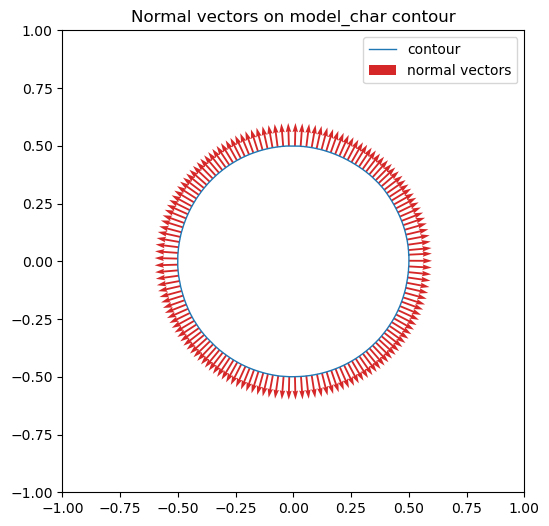

In [ ]:
pts = contour_tensor.detach().cpu().numpy()
nrm = norm_contour.detach().cpu().numpy()

# Subsample for readability
step = max(1, len(pts) // 150)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(pts[:, 0], pts[:, 1], color='tab:blue', linewidth=1.0, label='contour')
ax.quiver(
    pts[::step, 0], pts[::step, 1],
    nrm[::step, 0], nrm[::step, 1],
    color='tab:red', scale=20, width=0.004, label='normal vectors'
)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
ax.set_title('Normal vectors on model_char contour')
ax.legend()
plt.savefig('./darcy_learned_pou/normals_on_contour.png')
plt.show()


## Actual model training ##

In [191]:
def res(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]

    res_1 = k(pde_in) * grad_u + v

    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]), create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]), create_graph=True)[0][:, 1]

    res_2 = v_1_x + v_2_y

    return res_1, res_2


In [193]:
model_ctx_u = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(g_D, u_0)
)

model_ctx_v_exp = ec.PerCharCtx(
    input_dim=2,
    output_dim=2,
    char_functions=[chi_learned, lambda x: 1 - chi_learned(x)],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hidden_layers_per_output=[[16, 16, 16], [16, 16, 16]],
    hard_enforce=True,
    constraint_functions=(h, v_0),
)

model_u_exp = mm.MLPModel(model_ctx_u).to(device)
model_v_exp = ec.PerCharModel(model_ctx_v_exp).to(device)
model_combined_exp = ec.MultiModel(model_u_exp, model_v_exp).to(device)

optim_combine_exp = torch.optim.Adam(model_combined_exp.parameters(), lr=5e-4)
sched_combine_exp = ReduceLROnPlateau(optim_combine_exp, factor=0.75, patience=2_000)


In [194]:
model_init_exp = copy.deepcopy(model_combined_exp)
print('Initial parameter snapshot saved for model_combined_exp.')


Initial parameter snapshot saved for model_combined_exp.


In [195]:
def loss_combined(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in = domain.interior.requires_grad_(True)

    pde_out = model(pde_in)
    u = pde_out[:, 0]
    v = pde_out[:, 1:]

    res_1, res_2 = res(u, v, pde_in)
    res_sq = res_1[:, 0]**2 + res_1[:, 1]**2

    contour_tensor_inp = contour_tensor.detach().requires_grad_(True)
    v_1_cont = model.models[1].experts[0](contour_tensor_inp)
    v_2_cont = model.models[1].experts[1](contour_tensor_inp)

    flux_v_1 = torch.sum(v_1_cont * norm_contour, dim=1)
    flux_v_2 = torch.sum(v_2_cont * norm_contour, dim=1)
    cont_loss = torch.mean((flux_v_1 - flux_v_2)**2)
    
    loss_1 = torch.mean(res_sq)
    loss_2 = torch.mean(res_2**2)

    return [loss_1, loss_2, cont_loss]


In [196]:
train_ctx = train.TrainingContext(
    model=model_combined_exp,
    domain=domain,
    optimizer=optim_combine_exp,
    loss_fn=loss_combined,
    epochs=120_000,
    monitor_gradient=True,
    monitor_lr=True,
)

domain.ctx.N_int = 10_000

loss_exp, loss_comps_exp = train.train_switch_to_lbfgs(
    train_ctx, lbfgs_lr=0.1, epochs_with_lbfgs=1_000
)


Loss at epoch 1 is: 2.4584734439849854. Total gradient norm: inf Current learing rate: 0.0005 
Loss at epoch 100 is: 0.37503495812416077. Total gradient norm: 0.8384089078798271 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.20409932732582092. Total gradient norm: 0.2585994518123987 Current learing rate: 0.0005 
Loss at epoch 300 is: 0.15601491928100586. Total gradient norm: 0.12054568855570354 Current learing rate: 0.0005 
Loss at epoch 400 is: 0.13215570151805878. Total gradient norm: 0.07309965865308313 Current learing rate: 0.0005 
Loss at epoch 500 is: 0.1222873330116272. Total gradient norm: 0.05325376732028913 Current learing rate: 0.0005 
Loss at epoch 600 is: 0.11658679693937302. Total gradient norm: 0.11386481060099501 Current learing rate: 0.0005 
Loss at epoch 700 is: 0.1125776395201683. Total gradient norm: 0.17999838125822096 Current learing rate: 0.0005 
Loss at epoch 800 is: 0.10580151528120041. Total gradient norm: 0.0446225004646944 Current learing rate: 0.0005

In [ ]:
def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    u = model(pde_input)[:, 0]
    u_grad = grad(u, pde_input, torch.ones_like(u), create_graph=True)[0]
    u_x, u_y = u_grad[:, 0], u_grad[:, 1]

    u_xx = grad(u_x, pde_input, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, pde_input, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

    return u_xx + u_yy


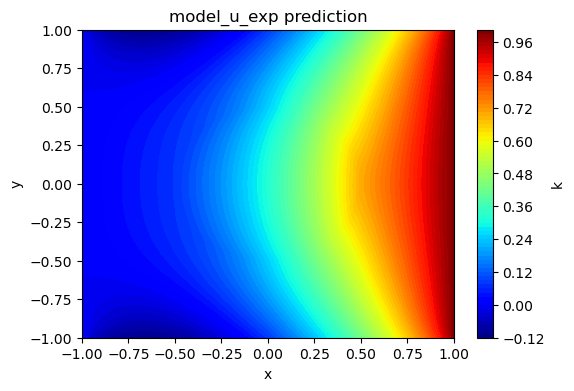

In [ ]:
plot_ctx.vmin = -0.12
plot_ctx.vmax = 1

plot_ctx.titles = ['model_u_exp prediction']
plot_ctx.save_path = './darcy_learned_pou/model_u_exp_pred.png'
utils.plot_function_on_2d_cube([lambda x: model_combined_exp(x)[:, 0]], plot_ctx)


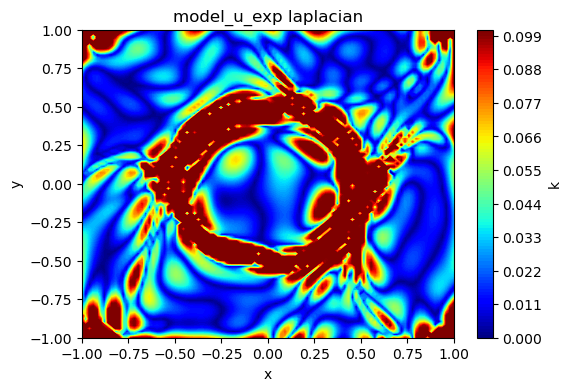

In [ ]:
plot_ctx.vmax = 0.1
plot_ctx.vmin = 0.0

plot_ctx.titles = ['model_u_exp laplacian']
plot_ctx.save_path = './darcy_learned_pou/model_u_exp_laplacian.png'
utils.plot_function_on_2d_cube(
    [lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model_combined_exp)), 0.0, 0.1)],
    plot_ctx
)


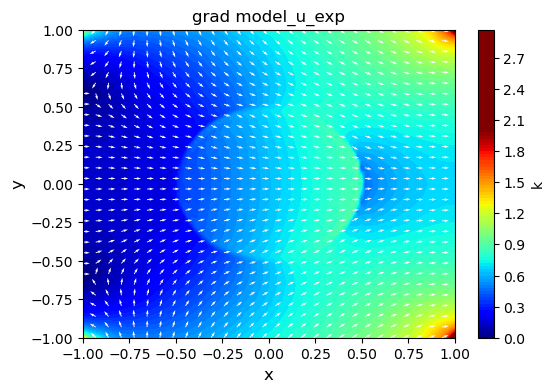

In [ ]:
plot_ctx.vmin = 0
plot_ctx.vmax = 2


def heat_flow(x, model):
    x.requires_grad_(True)
    u = model(x)[:, 0]
    return grad(u, x, torch.ones_like(u))[0]


plot_ctx.titles = ['grad model_u_exp']
plot_ctx.save_path = './darcy_learned_pou/model_u_exp_grad.png'
utils.plot_vector_field_2d(
    [lambda x: heat_flow(x, model_combined_exp)], plot_ctx, N=100, n_heigth=30, n_width=30
)


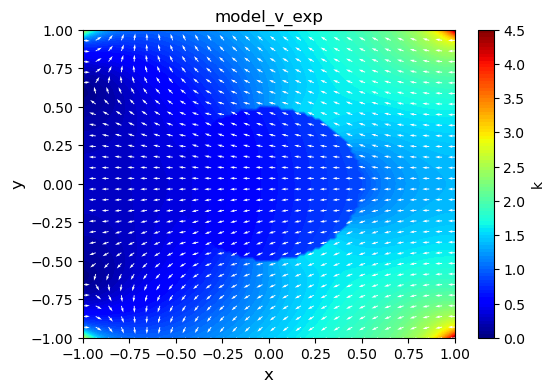

In [ ]:
plot_ctx.vmin = 0
plot_ctx.vmax = 4.5

plot_ctx.titles = ['model_v_exp']
plot_ctx.save_path = './darcy_learned_pou/model_v_exp.png'
utils.plot_vector_field_2d(
    [lambda x: model_combined_exp(x)[:, 1:]], plot_ctx, N=100, n_heigth=30, n_width=30
)


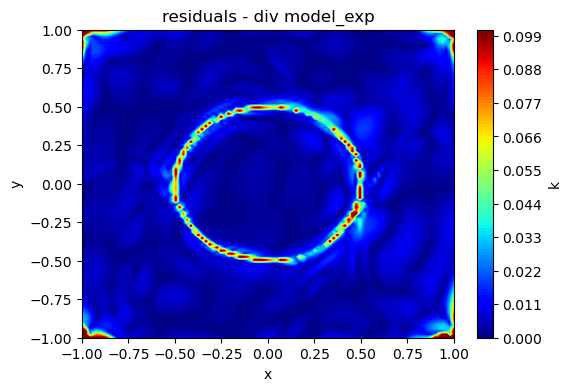

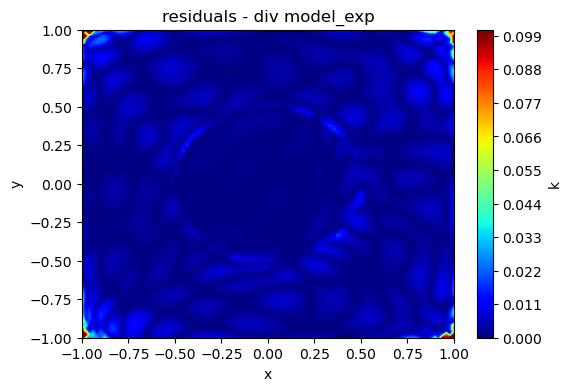

In [ ]:
plot_ctx.vmax = 0.1
plot_ctx.vmin = 0.0


def res_div_helper(x, model):
    x.requires_grad_(True)
    out = model(x)
    u = out[:, 0]
    v = out[:, 1:]
    res_1, res_2 = res(u, v, x)
    return torch.norm(res_1, p=2, dim=1), res_2


plot_ctx.titles = ['residuals - div model_exp']
plot_ctx.save_path = './darcy_learned_pou/model_v_exp_equation.png'
utils.plot_function_on_2d_cube(
    [lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_exp)[0]), 0.0, 0.1)],
    plot_ctx
)

plot_ctx.save_path = './darcy_learned_pou/model_v_exp_div.png'
utils.plot_function_on_2d_cube(
    [lambda x: torch.clamp(torch.abs(res_div_helper(x, model_combined_exp)[1]), 0.0, 0.1)],
    plot_ctx
)


In [218]:
zero_2d = lambda x: torch.zeros(x.shape[0], 2, device=x.device)
zero_1d = lambda x: torch.zeros(x.shape[0], 1, device=x.device)


def make_res1_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        r1, _ = res(u, v, x)
        return r1  # (N, 2)
    return f


def make_res2_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        _, r2 = res(u, v, x)
        return r2.unsqueeze(1)  # (N, 1)
    return f


l2_r1 = L2_norm(make_res1_fn(model_combined_exp), zero_2d,
                input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)
l2_r2 = L2_norm(make_res2_fn(model_combined_exp), zero_1d,
                input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS, device=str(device), n=50)

print(f"{'Model':<20}  {'L2 ||res1||':>12}  {'L2 ||res2||':>12}")
print('-' * 48)
print(f"{'combined_exp':<20}  {l2_r1.item():>12.6e}  {l2_r2.item():>12.6e}")


Model                  L2 ||res1||   L2 ||res2||
------------------------------------------------
combined_exp          5.992405e-02  2.031809e-02


/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


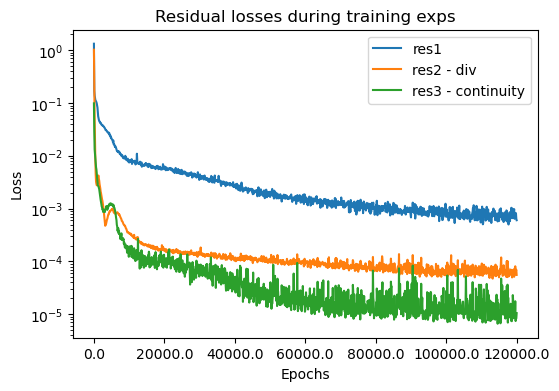

In [ ]:
plot_ctx.y_label = 'Loss'
plot_ctx.x_label = 'Epochs'

plot_ctx.titles = ['Residual losses during training exps']
plot_ctx.save_path = './darcy_learned_pou/model_exps_losses.png'
utils.plot_loss_values(
    {'res1': loss_comps_exp[0], 'res2 - div': loss_comps_exp[1], 'res3 - continuity': loss_comps_exp[2]},
    plot_ctx
)


In [220]:
with h5py.File('darcy_solution.h5', 'r') as f:
    xy_np    = f['samples/xy'][:]           # (N, 2)
    u_fem    = f['samples/u_interp'][:]     # (N,)
    v_fem_np = f['samples/flux_interp'][:]  # (N, 2)

xy_fem  = torch.tensor(xy_np,    dtype=torch.float32, device=device)
u_fem_t = torch.tensor(u_fem,    dtype=torch.float32, device=device)
v_fem_t = torch.tensor(v_fem_np, dtype=torch.float32, device=device)

u_true_norm  = torch.linalg.vector_norm(u_fem_t, ord=2)
v_true_norm  = torch.linalg.vector_norm(v_fem_t.reshape(-1), ord=2)
vx_true_norm = torch.linalg.vector_norm(v_fem_t[:, 0], ord=2)
vy_true_norm = torch.linalg.vector_norm(v_fem_t[:, 1], ord=2)

model_combined_exp.eval()
with torch.no_grad():
    out    = model_combined_exp(xy_fem)
    u_pred = out[:, 0]
    v_pred = out[:, 1:]

    u_err     = (u_pred - u_fem_t).abs()
    u_l2      = torch.linalg.vector_norm(u_err, ord=2)
    u_rel_l2  = u_l2 / (u_true_norm + 1e-12)
    u_rmse    = torch.sqrt(torch.mean((u_pred - u_fem_t)**2))

    v_err_mag = torch.norm(v_pred - v_fem_t, dim=1, p=2)
    v_l2      = torch.linalg.vector_norm(v_err_mag, ord=2)
    v_rel_l2  = v_l2 / (v_true_norm + 1e-12)
    v_rmse    = torch.sqrt(torch.mean((v_pred - v_fem_t)**2))

    vx_err    = (v_pred[:, 0] - v_fem_t[:, 0]).abs()
    vx_l2     = torch.linalg.vector_norm(vx_err, ord=2)
    vx_rel_l2 = vx_l2 / (vx_true_norm + 1e-12)
    vx_rmse   = torch.sqrt(torch.mean((v_pred[:, 0] - v_fem_t[:, 0])**2))

    vy_err    = (v_pred[:, 1] - v_fem_t[:, 1]).abs()
    vy_l2     = torch.linalg.vector_norm(vy_err, ord=2)
    vy_rel_l2 = vy_l2 / (vy_true_norm + 1e-12)
    vy_rmse   = torch.sqrt(torch.mean((v_pred[:, 1] - v_fem_t[:, 1])**2))

header = (f"{'Model':<20}  {'u L2':>10}  {'u RelL2':>10}  {'u RMSE':>10}"
          f"  {'v L2':>10}  {'v RelL2':>10}  {'v RMSE':>10}"
          f"  {'vx L2':>10}  {'vx RelL2':>10}  {'vx RMSE':>10}"
          f"  {'vy L2':>10}  {'vy RelL2':>10}  {'vy RMSE':>10}")
print(header)
print('-' * len(header))
print(f"{'combined_exp':<20}  {u_l2.item():>10.4e}  {u_rel_l2.item():>10.4e}  {u_rmse.item():>10.4e}"
      f"  {v_l2.item():>10.4e}  {v_rel_l2.item():>10.4e}  {v_rmse.item():>10.4e}"
      f"  {vx_l2.item():>10.4e}  {vx_rel_l2.item():>10.4e}  {vx_rmse.item():>10.4e}"
      f"  {vy_l2.item():>10.4e}  {vy_rel_l2.item():>10.4e}  {vy_rmse.item():>10.4e}")


Model                       u L2     u RelL2      u RMSE        v L2     v RelL2      v RMSE       vx L2    vx RelL2     vx RMSE       vy L2    vy RelL2     vy RMSE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
combined_exp          1.9864e-01  4.3074e-03  1.9864e-03         nan         nan         nan         nan         nan         nan         nan         nan         nan


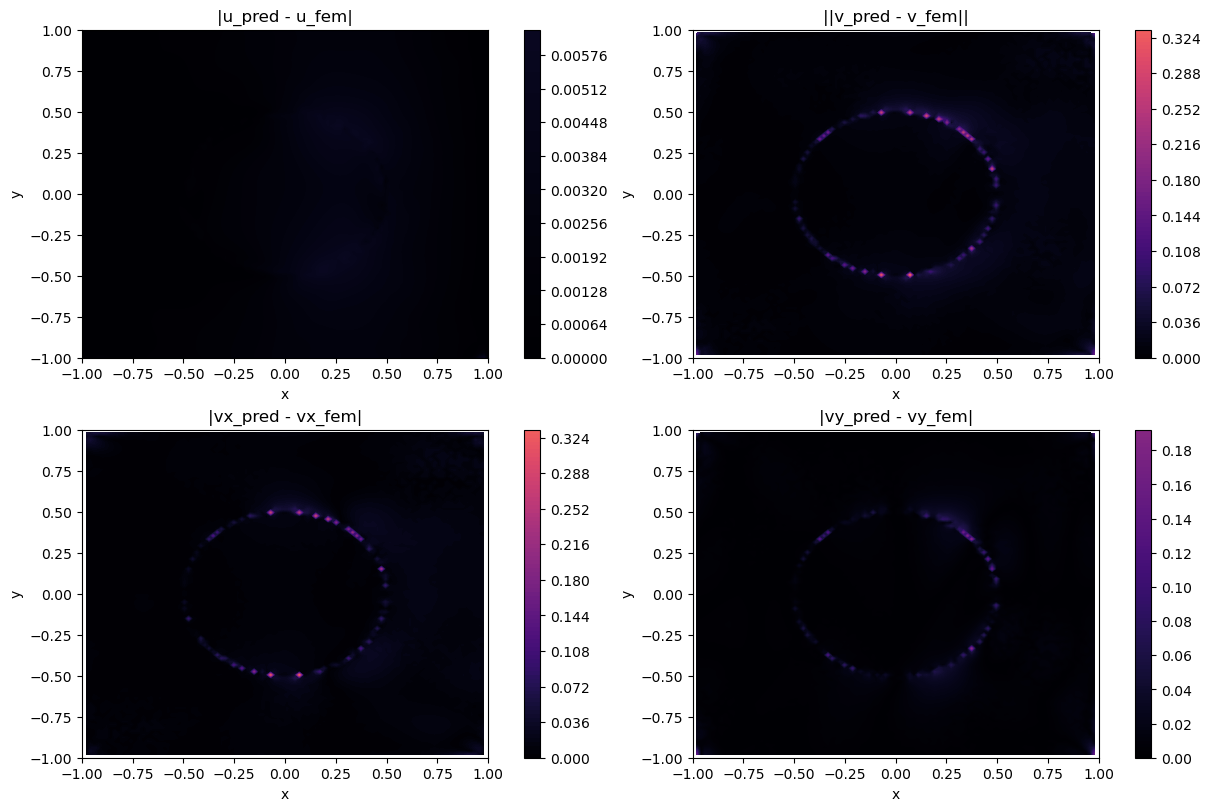

In [ ]:
xs = np.unique(xy_np[:, 0])
ys = np.unique(xy_np[:, 1])
nx, ny = len(xs), len(ys)
X = xy_np[:, 0].reshape(nx, ny)
Y = xy_np[:, 1].reshape(nx, ny)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

c1 = axes[0, 0].contourf(X, Y, u_err.cpu().numpy().reshape(nx, ny),
                          levels=100, cmap='magma', vmin=0.0, vmax=0.1)
axes[0, 0].set_title('|u_pred - u_fem|')
axes[0, 0].set_xlabel('x'); axes[0, 0].set_ylabel('y')
fig.colorbar(c1, ax=axes[0, 0])

c2 = axes[0, 1].contourf(X, Y, v_err_mag.cpu().numpy().reshape(nx, ny),
                          levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[0, 1].set_title('||v_pred - v_fem||')
axes[0, 1].set_xlabel('x'); axes[0, 1].set_ylabel('y')
fig.colorbar(c2, ax=axes[0, 1])

c3 = axes[1, 0].contourf(X, Y, vx_err.cpu().numpy().reshape(nx, ny),
                          levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[1, 0].set_title('|vx_pred - vx_fem|')
axes[1, 0].set_xlabel('x'); axes[1, 0].set_ylabel('y')
fig.colorbar(c3, ax=axes[1, 0])

c4 = axes[1, 1].contourf(X, Y, vy_err.cpu().numpy().reshape(nx, ny),
                          levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[1, 1].set_title('|vy_pred - vy_fem|')
axes[1, 1].set_xlabel('x'); axes[1, 1].set_ylabel('y')
fig.colorbar(c4, ax=axes[1, 1])

plt.savefig('./darcy_learned_pou/model_errors_exp_all.png')
plt.show()


In [205]:
learned = model_combined_exp.state_dict()
initial = model_init_exp.state_dict()
deltas = [(learned[k].float() - initial[k].float()).abs() for k in learned]
max_drift  = max(d.max().item() for d in deltas)
mean_drift = sum(d.mean().item() for d in deltas) / len(deltas)

print(f"{'Model':<20}  {'Max |Delta param|':>17}  {'Mean |Delta param|':>18}")
print('-' * 60)
print(f"{'combined_exp':<20}  {max_drift:>17.6e}  {mean_drift:>18.6e}")


Model                 Max |Delta param|  Mean |Delta param|
------------------------------------------------------------
combined_exp               7.837409e+00        1.945572e-01
